pvals shape: (19, 100, 2, 5)


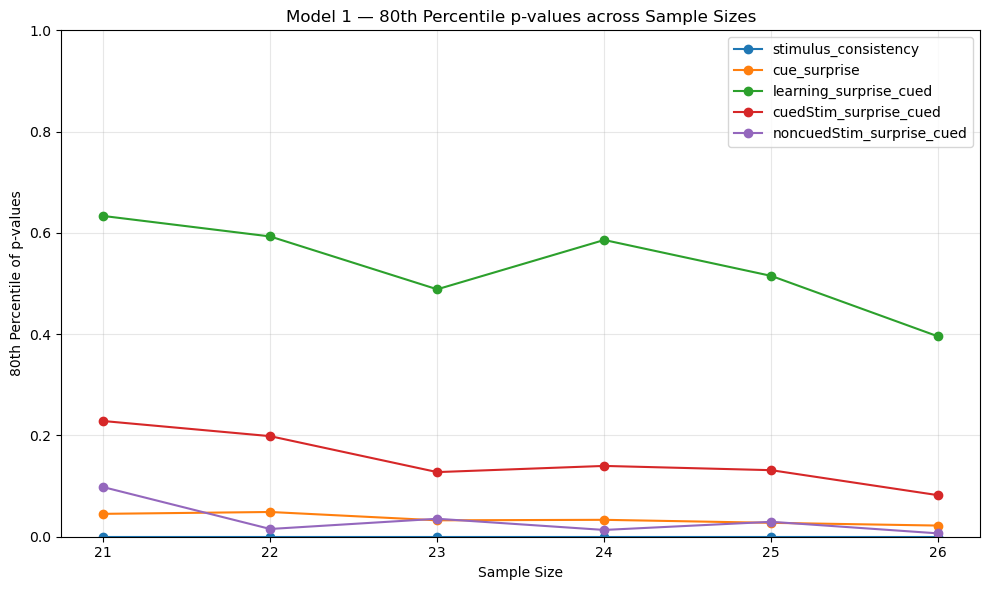

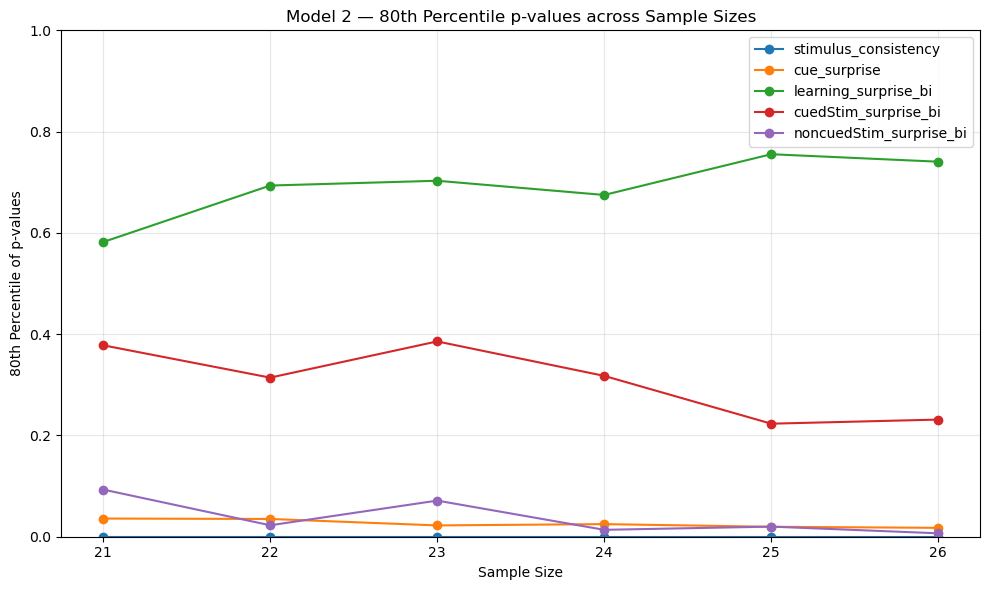

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load results
# -----------------------------
data = np.load("pupil_power_progress.npz", allow_pickle=True)
pvals = data["pvals"]          # shape = (n_sizes, n_repeats, 2, 5)
sample_sizes = data["sample_sizes"]  # list of sample sizes

n_sizes, n_repeats, n_models, n_predictors = pvals.shape
print("pvals shape:", pvals.shape)

# Predictor names must match your models
model_predictors = {
    0: ["stimulus_consistency", "cue_surprise", "learning_surprise_cued",
        "cuedStim_surprise_cued", "noncuedStim_surprise_cued"],

    1: ["stimulus_consistency", "cue_surprise", "learning_surprise_bi",
        "cuedStim_surprise_bi", "noncuedStim_surprise_bi"]
}

# -----------------------------
# Compute 80th percentiles
# -----------------------------

# perc80[model][predictor][sample_size_index]
perc80 = np.percentile(pvals, 80, axis=1)   # shape: (n_sizes, 2, 5)

# After percentile: shape = (n_sizes, 2, 5)
# Convert to (2 models, 5 predictors, n_sizes) for easier plotting
perc80 = np.transpose(perc80, (1, 2, 0))

# -----------------------------
# Plot each model
# -----------------------------
for model_index in [0, 1]:
    predictors = model_predictors[model_index]

    plt.figure(figsize=(10, 6))
    for pred_index, pred_name in enumerate(predictors):
        plt.plot(sample_sizes,
                 perc80[model_index][pred_index],
                 marker='o',
                 label=pred_name)

    plt.xlabel("Sample Size")
    plt.ylabel("80th Percentile of p-values")
    plt.title(f"Model {model_index+1} — 80th Percentile p-values across Sample Sizes")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [30]:
import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import beta as beta_dist
from functions import DataAnalyze_new, get_information_gain, kl_beta

version = 'v2'
eye_directory = f'data/processed/{version}/eyetracking'
main_directory = f'data/processed/{version}'

included_folders = [
    # '25-11-14-1255_setting0',
    '25-11-11-1259_setting0',
    '25-11-14-1455_setting0',
    '25-11-14-1354_setting0',
    '25-11-18-1258_setting0',
    '25-11-11-1358_setting0',
    '25-11-18-1456_setting0',
    '25-11-13-1307_setting0',
    '25-11-18-1213_setting0',
    '25-11-13-1214_setting0'
]

# ------------------------
# Functions
# ------------------------
def cum_counts_cued(block_df):
    block_df['cumA_beforetrial_cued'] = block_df['is_cued_A'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_cued'] = block_df['is_cued_B'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_cued'] = block_df['is_cued_A'].cumsum() + 1
    block_df['cumB_aftertrial_cued'] = block_df['is_cued_B'].cumsum() + 1
    return block_df

def cum_counts_bilateral(block_df):
    block_df['cumA_beforetrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum() + 1
    block_df['cumB_aftertrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum() + 1
    return block_df

def process_folder(folder, subject_id):
    """Process one folder and return a DataFrame with pupil data and computed variables."""
    baseline_file = os.path.join(eye_directory, folder, 'baseline_with_pupilSound.csv')
    if not os.path.exists(baseline_file):
        print(f"⚠️ Missing file for {folder}, skipping")
        return None
    
    pupil = pd.read_csv(baseline_file)
    participant = DataAnalyze_new(folder, main_directory)
    print(f"📂 Loading data from {folder}")

    # DEBUG: Check initial sizes
    print(f"🔍 DEBUG: Initial sizes")
    print(f"  pupil (baseline file): {len(pupil)} rows")
    print(f"  participant.log_data: {len(participant.log_data)} rows")

    # Add metadata
    pupil['subject'] = subject_id
    pupil['block_index'] = participant.log_data['block_index']
    pupil['trial_index_within_block'] = participant.log_data['trial_index_within_block']
    pupil['stimulus_consistency'] = participant.log_data['stimulus_consistency']
    pupil['block_entropy'] = participant.log_data['block_entropy']
    pupil['performance'] = participant.log_data['performance']


    left_stim = participant.log_data['stimulus'].str[0]
    right_stim = participant.log_data['stimulus'].str[2]
    cued_stim = np.where(participant.log_data['cue_direction']=='left', left_stim, right_stim)
    noncued_stim = np.where(participant.log_data['cue_direction']=='right', left_stim, right_stim)

    stiminfo = pd.DataFrame({
        'block_index': participant.log_data['block_index'],
        'left_stim': left_stim,
        'right_stim': right_stim,
        'cued_stim': pd.Series(cued_stim),
        'noncued_stim': pd.Series(noncued_stim)
    })

    # print(f"🔍 DEBUG: cuedstim before groupby: {len(cuedstim)} rows")


    # ---- Cued counts ----
    cuedstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                             'cued_stim': cued_stim})
    cuedstim['is_cued_A'] = (cuedstim['cued_stim']=='A').astype(int)
    cuedstim['is_cued_B'] = (cuedstim['cued_stim']=='B').astype(int)
    cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
    cuedstim['priorAprob_cued'] = cuedstim['cumA_beforetrial_cued'] / (cuedstim['cumA_beforetrial_cued'] + cuedstim['cumB_beforetrial_cued'])
    cuedstim['priorBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_beforetrial_cued'], row['cumB_beforetrial_cued']), axis=1)
    cuedstim['postBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_aftertrial_cued'], row['cumB_aftertrial_cued']), axis=1)
    pupil['learning_surprise_cued'] = cuedstim.apply(lambda row: kl_beta(row['priorBeta_cued'], row['postBeta_cued']), axis=1)
    pupil['cuedStim_surprise_cued'] = np.where(stiminfo['cued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))
    pupil['noncuedStim_surprise_cued'] = np.where(stiminfo['noncued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))

    # ---- Bilateral counts ----
    bilateralstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                                  'left_stim': left_stim, 'right_stim': right_stim})
    bilateralstim['is_left_A'] = (bilateralstim['left_stim']=='A').astype(int)
    bilateralstim['is_left_B'] = (bilateralstim['left_stim']=='B').astype(int)
    bilateralstim['is_right_A'] = (bilateralstim['right_stim']=='A').astype(int)
    bilateralstim['is_right_B'] = (bilateralstim['right_stim']=='B').astype(int)
    bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
    bilateralstim['priorAprob_bi'] = bilateralstim['cumA_beforetrial_bi'] / (bilateralstim['cumA_beforetrial_bi'] + bilateralstim['cumB_beforetrial_bi'])
    bilateralstim['priorBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_beforetrial_bi'], row['cumB_beforetrial_bi']), axis=1)
    bilateralstim['postBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_aftertrial_bi'], row['cumB_aftertrial_bi']), axis=1)
    pupil['learning_surprise_bi'] = bilateralstim.apply(lambda row: kl_beta(row['priorBeta_bi'], row['postBeta_bi']), axis=1)
    pupil['cuedStim_surprise_bi'] = np.where(stiminfo['cued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))
    pupil['noncuedStim_surprise_bi'] = np.where(stiminfo['noncued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))

    # ---- Cue surprise ----
    participant.log_data = get_information_gain(participant.log_data)
    cue = participant.log_data['cue_direction']
    subjective_leftcue_prob = participant.log_data['cue_learning_posterior'].apply(lambda b: b.mean())
    cue_prob = np.where(cue=='left', subjective_leftcue_prob, 1-subjective_leftcue_prob)
    pupil['cue_surprise'] = -np.log(cue_prob)

    return pupil

pupil_data_list = []
subject_count = 0

for folder in included_folders:
    subject_count += 1
    pupil = process_folder(folder, subject_count)
    if pupil is not None:
        pupil_data_list.append(pupil)

all_pupil = pd.concat(pupil_data_list, ignore_index=True)
all_pupil['max_pupilRatio'] = all_pupil['max_pupilSound'] / all_pupil['baseline']
all_pupil = all_pupil[all_pupil['performance']=="Correct"].copy()

📂 Loading data from 25-11-11-1259_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/3361113759.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/3361113759.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-11-14-1455_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/3361113759.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/3361113759.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-11-14-1354_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


...

/tmp/ipykernel_1134091/3361113759.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/3361113759.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-11-18-1213_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/3361113759.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/3361113759.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-11-13-1214_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/3361113759.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/3361113759.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


## partial correlation

In [43]:
import statsmodels.api as sm
from scipy.stats import pearsonr

# List of pupil metrics
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio', 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

# Function to get residuals after regressing X on control
def get_residuals(X, control):
    control = sm.add_constant(control)
    model = sm.OLS(X, control).fit()
    return model.resid

# Loop over metrics
for metric in pupil_metrics:
    # Compute pupil ratio relative to baseline
    Y = all_pupil[metric] / all_pupil['baseline']
    
    # Drop NaNs in relevant columns
    data = all_pupil[['cuedStim_surprise_cued', 'learning_surprise_cued']].copy()
    data[metric] = Y
    data = data.dropna()
    
    X1 = data['cuedStim_surprise_cued']
    X2 = data['learning_surprise_cued']
    Y_clean = data[metric]
    
    # Partial correlation 1: cuedStim -> pupil metric | learning
    res_X1 = get_residuals(X1, X2)
    res_Y1 = get_residuals(Y_clean, X2)
    mask1 = ~np.isnan(res_X1) & ~np.isnan(res_Y1)
    r1, p1 = pearsonr(res_X1[mask1], res_Y1[mask1])
    
    # Partial correlation 2: learning -> pupil metric | cuedStim
    res_X2 = get_residuals(X2, X1)
    res_Y2 = get_residuals(Y_clean, X1)
    mask2 = ~np.isnan(res_X2) & ~np.isnan(res_Y2)
    r2, p2 = pearsonr(res_X2[mask2], res_Y2[mask2])
    
    print(f"=== {metric} ===")
    print(f"Partial correlation (cuedStim -> {metric} | learning): r = {r1:.3f}, p = {p1:.3f}")
    print(f"Partial correlation (learning -> {metric} | cuedStim): r = {r2:.3f}, p = {p2:.3f}\n")


=== max_pupilRatio ===
Partial correlation (cuedStim -> max_pupilRatio | learning): r = 0.053, p = 0.010
Partial correlation (learning -> max_pupilRatio | cuedStim): r = -0.114, p = 0.000

=== mean_pupilSound_ratio ===
Partial correlation (cuedStim -> mean_pupilSound_ratio | learning): r = 0.056, p = 0.007
Partial correlation (learning -> mean_pupilSound_ratio | cuedStim): r = -0.113, p = 0.000

=== median_pupilSound_ratio ===
Partial correlation (cuedStim -> median_pupilSound_ratio | learning): r = 0.057, p = 0.006
Partial correlation (learning -> median_pupilSound_ratio | cuedStim): r = -0.112, p = 0.000

=== max_pupilSound_diff ===
Partial correlation (cuedStim -> max_pupilSound_diff | learning): r = 0.047, p = 0.022
Partial correlation (learning -> max_pupilSound_diff | cuedStim): r = 0.005, p = 0.809

=== mean_pupilSound_diff ===
Partial correlation (cuedStim -> mean_pupilSound_diff | learning): r = 0.051, p = 0.013
Partial correlation (learning -> mean_pupilSound_diff | cuedStim)

## partial out stim consistency as well

In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import pearsonr

all_pupil['mean_pupilSound_ratio'] = all_pupil['mean_pupilSound'] / all_pupil['baseline']
all_pupil['median_pupilSound_ratio'] = all_pupil['median_pupilSound'] / all_pupil['baseline']

all_pupil['mean_pupilSound_diff'] = all_pupil['mean_pupilSound'] - all_pupil['baseline']
all_pupil['median_pupilSound_diff'] = all_pupil['median_pupilSound'] - all_pupil['baseline']
all_pupil['max_pupilSound_diff'] = all_pupil['max_pupilSound'] - all_pupil['baseline']


# List of pupil metrics
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio', 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

# Function to get residuals after regressing X on controls
def get_residuals(X, controls):
    # Ensure inputs are numeric arrays
    X = np.asarray(X, dtype=float)
    controls = np.asarray(controls, dtype=float)
    controls = sm.add_constant(controls)
    model = sm.OLS(X, controls).fit()
    return model.resid

# Prepare a list to store results
results = []

for metric in pupil_metrics:
    # Compute pupil ratio relative to baseline
    Y = all_pupil[metric] / all_pupil['baseline']
    
    # Keep relevant columns
    data = all_pupil[['cuedStim_surprise_cued', 'learning_surprise_cued', 'stimulus_consistency']].copy()
    data[metric] = Y
    
    # Drop rows with NaNs
    data = data.dropna(subset=['cuedStim_surprise_cued', 'learning_surprise_cued', 'stimulus_consistency', metric])
    
    # Convert all relevant columns to numeric, coercing errors to NaN
    X1 = pd.to_numeric(data['cuedStim_surprise_cued'], errors='coerce')
    X2 = pd.to_numeric(data['learning_surprise_cued'], errors='coerce')
    SC = pd.to_numeric(data['stimulus_consistency'], errors='coerce')
    Y_clean = pd.to_numeric(data[metric], errors='coerce')
    
    # Drop rows with non-finite values
    mask = np.isfinite(X1) & np.isfinite(X2) & np.isfinite(SC) & np.isfinite(Y_clean)
    X1, X2, SC, Y_clean = X1[mask], X2[mask], SC[mask], Y_clean[mask]
    
    # Ensure we have enough data points
    if len(X1) < 3:  # Need at least 3 points for regression with 2 controls + intercept
        print(f"Warning: Not enough data points for {metric}. Skipping.")
        continue
    
    try:
        # Partial correlation 1: cuedStim -> pupil | learning + stimulus_consistency
        controls1 = np.column_stack([X2, SC])
        res_X1 = get_residuals(X1, controls1)
        res_Y1 = get_residuals(Y_clean, controls1)
        r1, p1 = pearsonr(res_X1, res_Y1)
        
        # Partial correlation 2: learning -> pupil | cuedStim + stimulus_consistency
        controls2 = np.column_stack([X1, SC])
        res_X2 = get_residuals(X2, controls2)
        res_Y2 = get_residuals(Y_clean, controls2)
        r2, p2 = pearsonr(res_X2, res_Y2)
        
        # Store results
        results.append({'pupil_metric': metric, 'predictor': 'cuedStim_surprise_cued', 
                        'partial_r': r1, 'p_value': p1, 'n_obs': len(X1)})
        results.append({'pupil_metric': metric, 'predictor': 'learning_surprise_cued', 
                        'partial_r': r2, 'p_value': p2, 'n_obs': len(X1)})
    
    except Exception as e:
        print(f"Error processing {metric}: {e}")
        continue

# Convert to DataFrame
if results:
    partial_corr_df = pd.DataFrame(results)
    print(partial_corr_df)
else:
    print("No results to display. Check your data.")

               pupil_metric               predictor  partial_r       p_value  \
0            max_pupilRatio  cuedStim_surprise_cued   0.023116  2.594284e-01   
1            max_pupilRatio  learning_surprise_cued  -0.107792  1.338573e-07   
2     mean_pupilSound_ratio  cuedStim_surprise_cued   0.024354  2.347701e-01   
3     mean_pupilSound_ratio  learning_surprise_cued  -0.106582  1.848737e-07   
4   median_pupilSound_ratio  cuedStim_surprise_cued   0.025477  2.138772e-01   
5   median_pupilSound_ratio  learning_surprise_cued  -0.106052  2.127160e-07   
6       max_pupilSound_diff  cuedStim_surprise_cued  -0.007286  7.222626e-01   
7       max_pupilSound_diff  learning_surprise_cued   0.016654  4.165268e-01   
8      mean_pupilSound_diff  cuedStim_surprise_cued  -0.006301  7.585689e-01   
9      mean_pupilSound_diff  learning_surprise_cued   0.025247  2.180521e-01   
10   median_pupilSound_diff  cuedStim_surprise_cued  -0.003056  8.814802e-01   
11   median_pupilSound_diff  learning_su

In [ ]:
predictors1 = ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"],
predictors2 = ["stimulus_consistency", "cue_surprise", "learning_surprise_bi", "cuedStim_surprise_bi", "noncuedStim_surprise_bi"]


## heatmap

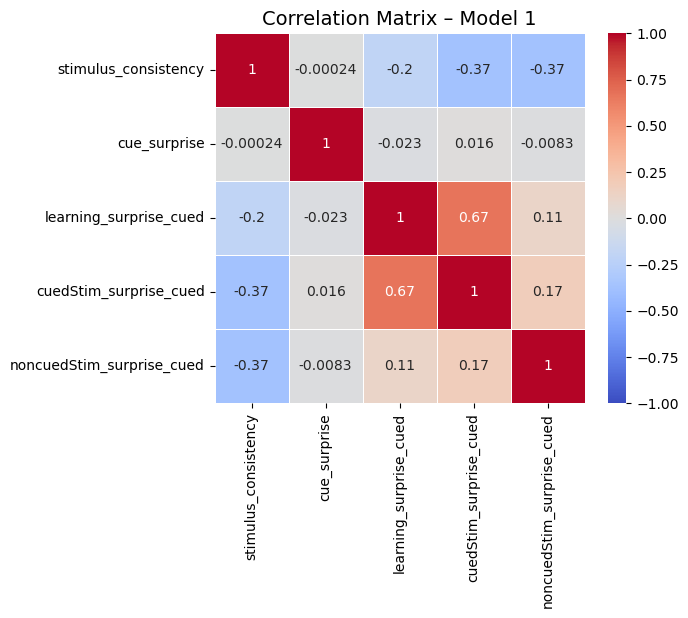

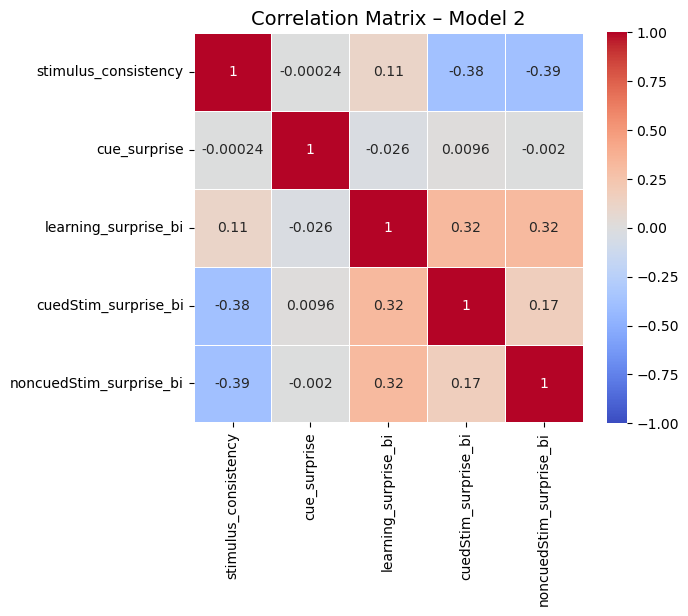

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

predictors1 = [
    "stimulus_consistency", "cue_surprise",
    "learning_surprise_cued", "cuedStim_surprise_cued",
    "noncuedStim_surprise_cued"
]

predictors2 = [
    "stimulus_consistency", "cue_surprise",
    "learning_surprise_bi", "cuedStim_surprise_bi",
    "noncuedStim_surprise_bi"
]

# Compute correlations
corr1 = all_pupil[predictors1].corr()
corr2 = all_pupil[predictors2].corr()

# --- heatmap function ---
def plot_corr_seaborn(corr, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        corr,
        annot=True,
        vmin=-1, vmax=1,        # >>> fixed color range <<<
        cmap="coolwarm",
        square=True,
        linewidths=0.5,
        linecolor="white"
    )
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# --- plot both ---
plot_corr_seaborn(corr1, "Correlation Matrix – Model 1")
plot_corr_seaborn(corr2, "Correlation Matrix – Model 2")


In [28]:
def fit_pupil_model(all_pupil, predictors):
    formula_cols = ["max_pupilRatio"] + predictors
    for col in formula_cols:
        all_pupil[col] = pd.to_numeric(all_pupil[col], errors='coerce')
    if 'stimulus_consistency' in predictors:
        all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)
    clean_data = all_pupil.dropna(subset=formula_cols)
    formula = "max_pupilRatio ~ " + " + ".join(predictors)
    model = smf.mixedlm(formula, clean_data, groups=clean_data["subject"]).fit(reml=True)
    return model

In [32]:
model1 = fit_pupil_model(all_pupil, ["stimulus_consistency", "cue_surprise", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"])
print(model1.summary())

                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    max_pupilRatio
No. Observations:    2382       Method:                REML          
No. Groups:          9          Scale:                 0.0097        
Min. group size:     256        Log-Likelihood:        2113.9219     
Max. group size:     269        Converged:             Yes           
Mean group size:     264.7                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.131    0.011 101.217 0.000  1.109  1.153
stimulus_consistency      -0.035    0.005  -7.083 0.000 -0.044 -0.025
cue_surprise               0.006    0.005   1.176 0.239 -0.004  0.017
cuedStim_surprise_cued     0.003    0.005   0.711 0.477 -0.006  0.012
noncuedStim_surprise_cued  0.007    

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [33]:
model1 = fit_pupil_model(all_pupil, ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "noncuedStim_surprise_cued"])
print(model1.summary())

                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    max_pupilRatio
No. Observations:    2382       Method:                REML          
No. Groups:          9          Scale:                 0.0097        
Min. group size:     256        Log-Likelihood:        2115.5906     
Max. group size:     269        Converged:             Yes           
Mean group size:     264.7                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.132    0.011 105.784 0.000  1.111  1.153
stimulus_consistency      -0.035    0.005  -7.504 0.000 -0.044 -0.026
cue_surprise               0.007    0.005   1.209 0.227 -0.004  0.017
learning_surprise_cued     0.019    0.021   0.920 0.357 -0.022  0.060
noncuedStim_surprise_cued  0.007    

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [31]:
model1 = fit_pupil_model(all_pupil, ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"])
print(model1.summary())

                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    max_pupilRatio
No. Observations:    2382       Method:                REML          
No. Groups:          9          Scale:                 0.0097        
Min. group size:     256        Log-Likelihood:        2111.4292     
Max. group size:     269        Converged:             Yes           
Mean group size:     264.7                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.132    0.011 101.022 0.000  1.110  1.154
stimulus_consistency      -0.035    0.005  -7.108 0.000 -0.045 -0.025
cue_surprise               0.007    0.005   1.202 0.229 -0.004  0.017
learning_surprise_cued     0.017    0.028   0.602 0.547 -0.037  0.071
cuedStim_surprise_cued     0.001    

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
model1 = fit_pupil_model(all_pupil, ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"])
print(model1.summary())

                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    max_pupilRatio
No. Observations:    2382       Method:                REML          
No. Groups:          9          Scale:                 0.0097        
Min. group size:     256        Log-Likelihood:        2111.4292     
Max. group size:     269        Converged:             Yes           
Mean group size:     264.7                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.132    0.011 101.022 0.000  1.110  1.154
stimulus_consistency      -0.035    0.005  -7.108 0.000 -0.045 -0.025
cue_surprise               0.007    0.005   1.202 0.229 -0.004  0.017
learning_surprise_cued     0.017    0.028   0.602 0.547 -0.037  0.071
cuedStim_surprise_cued     0.001    

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## bi learning

In [50]:
model2 = fit_pupil_model(all_pupil, ["stimulus_consistency", "cue_surprise", "learning_surprise_bi", "cuedStim_surprise_bi", "noncuedStim_surprise_bi"])
print(model2.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:   2382      Method:               REML          
No. Groups:         9         Scale:                0.0096        
Min. group size:    256       Log-Likelihood:       2113.3310     
Max. group size:    269       Converged:            Yes           
Mean group size:    264.7                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                1.134    0.011 98.658 0.000  1.111  1.156
stimulus_consistency    -0.037    0.005 -6.880 0.000 -0.048 -0.027
cue_surprise             0.007    0.005  1.235 0.217 -0.004  0.017
learning_surprise_bi     0.025    0.014  1.765 0.078 -0.003  0.052
cuedStim_surprise_bi    -0.001    0.005 -0.119 0.905 -0.011  0.009
noncuedSti

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### partial correlation

In [52]:
import statsmodels.api as sm
from scipy.stats import pearsonr

# List of pupil metrics
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio', 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

# Function to get residuals after regressing X on control
def get_residuals(X, control):
    control = sm.add_constant(control)
    model = sm.OLS(X, control).fit()
    return model.resid

# Loop over metrics
for metric in pupil_metrics:
    # Compute pupil ratio relative to baseline
    Y = all_pupil[metric] / all_pupil['baseline']
    
    # Drop NaNs in relevant columns
    data = all_pupil[['cuedStim_surprise_bi', 'learning_surprise_bi']].copy()
    data[metric] = Y
    data = data.dropna()
    
    X1 = data['cuedStim_surprise_bi']
    X2 = data['learning_surprise_bi']
    Y_clean = data[metric]
    
    # Partial correlation 1: cuedStim -> pupil metric | learning
    res_X1 = get_residuals(X1, X2)
    res_Y1 = get_residuals(Y_clean, X2)
    mask1 = ~np.isnan(res_X1) & ~np.isnan(res_Y1)
    r1, p1 = pearsonr(res_X1[mask1], res_Y1[mask1])
    
    # Partial correlation 2: learning -> pupil metric | cuedStim
    res_X2 = get_residuals(X2, X1)
    res_Y2 = get_residuals(Y_clean, X1)
    mask2 = ~np.isnan(res_X2) & ~np.isnan(res_Y2)
    r2, p2 = pearsonr(res_X2[mask2], res_Y2[mask2])
    
    print(f"=== {metric} ===")
    print(f"Partial correlation (cuedStim -> {metric} | learning): r = {r1:.3f}, p = {p1:.3f}")
    print(f"Partial correlation (learning -> {metric} | cuedStim): r = {r2:.3f}, p = {p2:.3f}\n")


=== max_pupilRatio ===
Partial correlation (cuedStim -> max_pupilRatio | learning): r = 0.010, p = 0.627
Partial correlation (learning -> max_pupilRatio | cuedStim): r = -0.100, p = 0.000

=== mean_pupilSound_ratio ===
Partial correlation (cuedStim -> mean_pupilSound_ratio | learning): r = 0.014, p = 0.482
Partial correlation (learning -> mean_pupilSound_ratio | cuedStim): r = -0.099, p = 0.000

=== median_pupilSound_ratio ===
Partial correlation (cuedStim -> median_pupilSound_ratio | learning): r = 0.016, p = 0.448
Partial correlation (learning -> median_pupilSound_ratio | cuedStim): r = -0.098, p = 0.000

=== max_pupilSound_diff ===
Partial correlation (cuedStim -> max_pupilSound_diff | learning): r = 0.064, p = 0.002
Partial correlation (learning -> max_pupilSound_diff | cuedStim): r = 0.006, p = 0.773

=== mean_pupilSound_diff ===
Partial correlation (cuedStim -> mean_pupilSound_diff | learning): r = 0.074, p = 0.000
Partial correlation (learning -> mean_pupilSound_diff | cuedStim)

In [51]:
# List of pupil metrics
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio', 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

# Function to get residuals after regressing X on controls
def get_residuals(X, controls):
    # Ensure inputs are numeric arrays
    X = np.asarray(X, dtype=float)
    controls = np.asarray(controls, dtype=float)
    controls = sm.add_constant(controls)
    model = sm.OLS(X, controls).fit()
    return model.resid

# Prepare a list to store results
results = []

for metric in pupil_metrics:
    # Compute pupil ratio relative to baseline
    Y = all_pupil[metric] / all_pupil['baseline']
    
    # Keep relevant columns
    data = all_pupil[['cuedStim_surprise_bi', 'learning_surprise_bi', 'stimulus_consistency']].copy()
    data[metric] = Y
    
    # Drop rows with NaNs
    data = data.dropna(subset=['cuedStim_surprise_bi', 'learning_surprise_bi', 'stimulus_consistency', metric])
    
    # Convert all relevant columns to numeric, coercing errors to NaN
    X1 = pd.to_numeric(data['cuedStim_surprise_bi'], errors='coerce')
    X2 = pd.to_numeric(data['learning_surprise_bi'], errors='coerce')
    SC = pd.to_numeric(data['stimulus_consistency'], errors='coerce')
    Y_clean = pd.to_numeric(data[metric], errors='coerce')
    
    # Drop rows with non-finite values
    mask = np.isfinite(X1) & np.isfinite(X2) & np.isfinite(SC) & np.isfinite(Y_clean)
    X1, X2, SC, Y_clean = X1[mask], X2[mask], SC[mask], Y_clean[mask]
    
    # Ensure we have enough data points
    if len(X1) < 3:  # Need at least 3 points for regression with 2 controls + intercept
        print(f"Warning: Not enough data points for {metric}. Skipping.")
        continue
    
    try:
        # Partial correlation 1: cuedStim -> pupil | learning + stimulus_consistency
        controls1 = np.column_stack([X2, SC])
        res_X1 = get_residuals(X1, controls1)
        res_Y1 = get_residuals(Y_clean, controls1)
        r1, p1 = pearsonr(res_X1, res_Y1)
        
        # Partial correlation 2: learning -> pupil | cuedStim + stimulus_consistency
        controls2 = np.column_stack([X1, SC])
        res_X2 = get_residuals(X2, controls2)
        res_Y2 = get_residuals(Y_clean, controls2)
        r2, p2 = pearsonr(res_X2, res_Y2)
        
        # Store results
        results.append({'pupil_metric': metric, 'predictor': 'cuedStim_surprise_bi', 
                        'partial_r': r1, 'p_value': p1, 'n_obs': len(X1)})
        results.append({'pupil_metric': metric, 'predictor': 'learning_surprise_bi', 
                        'partial_r': r2, 'p_value': p2, 'n_obs': len(X1)})
    
    except Exception as e:
        print(f"Error processing {metric}: {e}")
        continue

# Convert to DataFrame
if results:
    partial_corr_df = pd.DataFrame(results)
    print(partial_corr_df)
else:
    print("No results to display. Check your data.")

               pupil_metric             predictor  partial_r   p_value  n_obs
0            max_pupilRatio  cuedStim_surprise_bi  -0.018968  0.354794   2382
1            max_pupilRatio  learning_surprise_bi  -0.080259  0.000088   2382
2     mean_pupilSound_ratio  cuedStim_surprise_bi  -0.017136  0.403169   2382
3     mean_pupilSound_ratio  learning_surprise_bi  -0.077491  0.000153   2382
4   median_pupilSound_ratio  cuedStim_surprise_bi  -0.016515  0.420436   2382
5   median_pupilSound_ratio  learning_surprise_bi  -0.075962  0.000207   2382
6       max_pupilSound_diff  cuedStim_surprise_bi  -0.014779  0.470926   2382
7       max_pupilSound_diff  learning_surprise_bi   0.050308  0.014066   2382
8      mean_pupilSound_diff  cuedStim_surprise_bi  -0.010589  0.605459   2382
9      mean_pupilSound_diff  learning_surprise_bi   0.062135  0.002414   2382
10   median_pupilSound_diff  cuedStim_surprise_bi  -0.008961  0.662036   2382
11   median_pupilSound_diff  learning_surprise_bi   0.064998  0.

# v1

In [33]:
# ------------------------
# Functions
# ------------------------
epsilon = 1e-6  # small pseudocount to avoid zeros

def cum_counts_cued(block_df):
    block_df['cumA_beforetrial_cued'] = block_df['is_cued_A'].cumsum().shift(1, fill_value=0) + epsilon
    block_df['cumB_beforetrial_cued'] = block_df['is_cued_B'].cumsum().shift(1, fill_value=0) + epsilon
    block_df['cumA_aftertrial_cued'] = block_df['is_cued_A'].cumsum() + epsilon
    block_df['cumB_aftertrial_cued'] = block_df['is_cued_B'].cumsum() + epsilon
    return block_df

def cum_counts_bilateral(block_df):
    block_df['cumA_beforetrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum().shift(1, fill_value=0) + epsilon
    block_df['cumB_beforetrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum().shift(1, fill_value=0) + epsilon
    block_df['cumA_aftertrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum() + epsilon
    block_df['cumB_aftertrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum() + epsilon
    return block_df

# def cum_counts_cued(block_df):
#     block_df['cumA_beforetrial_cued'] = block_df['is_cued_A'].cumsum().shift(1, fill_value=0) + 1
#     block_df['cumB_beforetrial_cued'] = block_df['is_cued_B'].cumsum().shift(1, fill_value=0) + 1
#     block_df['cumA_aftertrial_cued'] = block_df['is_cued_A'].cumsum() + 1
#     block_df['cumB_aftertrial_cued'] = block_df['is_cued_B'].cumsum() + 1
#     return block_df

# def cum_counts_bilateral(block_df):
#     block_df['cumA_beforetrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum().shift(1, fill_value=0) + 1
#     block_df['cumB_beforetrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum().shift(1, fill_value=0) + 1
#     block_df['cumA_aftertrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum() + 1
#     block_df['cumB_aftertrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum() + 1
#     return block_df

def process_folder(folder, subject_id):
    """Process one folder and return a DataFrame with pupil data and computed variables."""
    baseline_file = os.path.join(eye_directory, folder, 'baseline_with_pupilSound.csv')
    if not os.path.exists(baseline_file):
        print(f"⚠️ Missing file for {folder}, skipping")
        return None
    
    pupil = pd.read_csv(baseline_file)
    participant = DataAnalyze_new(folder, main_directory)
    print(f"📂 Loading data from {folder}")

    # DEBUG: Check initial sizes
    print(f"🔍 DEBUG: Initial sizes")
    print(f"  pupil (baseline file): {len(pupil)} rows")
    print(f"  participant.log_data: {len(participant.log_data)} rows")

    # Add metadata
    pupil['subject'] = subject_id
    pupil['block_index'] = participant.log_data['block_index']
    pupil['trial_index_within_block'] = participant.log_data['trial_index_within_block']
    pupil['stimulus_consistency'] = participant.log_data['stimulus_consistency']
    pupil['block_entropy'] = participant.log_data['block_entropy']
    pupil['performance'] = participant.log_data['performance']


    left_stim = participant.log_data['stimulus'].str[0]
    right_stim = participant.log_data['stimulus'].str[2]
    cued_stim = np.where(participant.log_data['cue_direction']=='left', left_stim, right_stim)
    noncued_stim = np.where(participant.log_data['cue_direction']=='right', left_stim, right_stim)

    stiminfo = pd.DataFrame({
        'block_index': participant.log_data['block_index'],
        'left_stim': left_stim,
        'right_stim': right_stim,
        'cued_stim': pd.Series(cued_stim),
        'noncued_stim': pd.Series(noncued_stim)
    })

    # print(f"🔍 DEBUG: cuedstim before groupby: {len(cuedstim)} rows")


    # ---- Cued counts ----
    cuedstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                             'cued_stim': cued_stim})
    cuedstim['is_cued_A'] = (cuedstim['cued_stim']=='A').astype(int)
    cuedstim['is_cued_B'] = (cuedstim['cued_stim']=='B').astype(int)
    cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
    cuedstim['priorAprob_cued'] = cuedstim['cumA_beforetrial_cued'] / (cuedstim['cumA_beforetrial_cued'] + cuedstim['cumB_beforetrial_cued'])
    cuedstim['priorBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_beforetrial_cued'], row['cumB_beforetrial_cued']), axis=1)
    cuedstim['postBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_aftertrial_cued'], row['cumB_aftertrial_cued']), axis=1)
    pupil['learning_surprise_cued'] = cuedstim.apply(lambda row: kl_beta(row['priorBeta_cued'], row['postBeta_cued']), axis=1)
    pupil['cuedStim_surprise_cued'] = np.where(stiminfo['cued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))
    pupil['noncuedStim_surprise_cued'] = np.where(stiminfo['noncued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))

    # ---- Bilateral counts ----
    bilateralstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                                  'left_stim': left_stim, 'right_stim': right_stim})
    bilateralstim['is_left_A'] = (bilateralstim['left_stim']=='A').astype(int)
    bilateralstim['is_left_B'] = (bilateralstim['left_stim']=='B').astype(int)
    bilateralstim['is_right_A'] = (bilateralstim['right_stim']=='A').astype(int)
    bilateralstim['is_right_B'] = (bilateralstim['right_stim']=='B').astype(int)
    bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
    bilateralstim['priorAprob_bi'] = bilateralstim['cumA_beforetrial_bi'] / (bilateralstim['cumA_beforetrial_bi'] + bilateralstim['cumB_beforetrial_bi'])
    bilateralstim['priorBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_beforetrial_bi'], row['cumB_beforetrial_bi']), axis=1)
    bilateralstim['postBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_aftertrial_bi'], row['cumB_aftertrial_bi']), axis=1)
    pupil['learning_surprise_bi'] = bilateralstim.apply(lambda row: kl_beta(row['priorBeta_bi'], row['postBeta_bi']), axis=1)
    pupil['cuedStim_surprise_bi'] = np.where(stiminfo['cued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))
    pupil['noncuedStim_surprise_bi'] = np.where(stiminfo['noncued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))

    # ---- Cue surprise ----
    participant.log_data = get_information_gain(participant.log_data)
    cue = participant.log_data['cue_direction']
    subjective_leftcue_prob = participant.log_data['cue_learning_posterior'].apply(lambda b: b.mean())
    cue_prob = np.where(cue=='left', subjective_leftcue_prob, 1-subjective_leftcue_prob)
    pupil['cue_surprise'] = -np.log(cue_prob)

    return pupil

In [2]:
import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import beta as beta_dist
from functions import DataAnalyze_new, get_information_gain, kl_beta

version = 'v1'
eye_directory = f'data/processed/{version}/eyetracking'
main_directory = f'data/processed/{version}'

included_folders = [
    '25-10-17-1206_setting0',
    '25-10-24-1302_setting0',
    '25-10-30-1254_setting0',
    '25-10-22-1358_setting0',
    '25-09-30-1530_setting0',
    '25-09-30-1338_setting0',
    '25-10-01-1417_setting0',
    '25-11-05-1457_setting0',
    '25-09-29-1238_setting0',
    '25-11-03-1151_setting0',
    '25-11-04-1404_setting0',
    # '25-11-07-1456_setting0',
    '25-11-05-1407_setting0',
    '25-09-30-1427_setting0',
    '25-10-08-1408_setting0',
    '25-10-20-1204_setting0',
    # '25-10-07-1513_setting0',
    '25-10-21-1446_setting0',
    # '25-11-05-1407_setting0',
    '25-10-23-1258_setting0',
    '25-09-30-1142_setting0',
    '25-10-24-1354_setting0',
    '25-10-20-1257_setting0',
    '25-11-03-1301_setting0',
    # '25-11-07-1401_setting0',
    # '25-11-06-1302_setting0'
]


pupil_data_list = []
subject_count = 0

for folder in included_folders:
    subject_count += 1
    pupil = process_folder(folder, subject_count)
    if pupil is not None:
        pupil_data_list.append(pupil)

all_pupil_v1 = pd.concat(pupil_data_list, ignore_index=True)
all_pupil_v1['max_pupilRatio'] = all_pupil_v1['max_pupilSound'] / all_pupil_v1['baseline']
all_pupil_v1 = all_pupil_v1[all_pupil_v1['performance']=="Correct"].copy()

📂 Loading data from 25-10-17-1206_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/102235188.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/102235188.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-10-24-1302_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/102235188.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/102235188.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-10-30-1254_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


...

/tmp/ipykernel_1134091/102235188.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/102235188.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-10-20-1257_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/102235188.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/102235188.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-11-03-1301_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1134091/102235188.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1134091/102235188.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


In [13]:
all_pupil_v1.columns

Index(['trial_index', 'baseline', 'max_pupilSound', 'mean_pupilSound',
       'median_pupilSound', 'subject', 'block_index',
       'trial_index_within_block', 'stimulus_consistency', 'block_entropy',
       'performance', 'learning_surprise_cued', 'cuedStim_surprise_cued',
       'noncuedStim_surprise_cued', 'learning_surprise_bi',
       'cuedStim_surprise_bi', 'noncuedStim_surprise_bi', 'cue_surprise',
       'max_pupilRatio'],
      dtype='object')

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import pearsonr

all_pupil_v1['mean_pupilSound_ratio'] = all_pupil_v1['mean_pupilSound'] / all_pupil_v1['baseline']
all_pupil_v1['median_pupilSound_ratio'] = all_pupil_v1['median_pupilSound'] / all_pupil_v1['baseline']

all_pupil_v1['mean_pupilSound_diff'] = all_pupil_v1['mean_pupilSound'] - all_pupil_v1['baseline']
all_pupil_v1['median_pupilSound_diff'] = all_pupil_v1['median_pupilSound'] - all_pupil_v1['baseline']
all_pupil_v1['max_pupilSound_diff'] = all_pupil_v1['max_pupilSound'] - all_pupil_v1['baseline']


# List of pupil metrics
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio', 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

# Function to get residuals after regressing X on controls
def get_residuals(X, controls):
    # Ensure inputs are numeric arrays
    X = np.asarray(X, dtype=float)
    controls = np.asarray(controls, dtype=float)
    controls = sm.add_constant(controls)
    model = sm.OLS(X, controls).fit()
    return model.resid

# Prepare a list to store results
results = []

for metric in pupil_metrics:
    # Compute pupil ratio relative to baseline
    Y = all_pupil_v1[metric] / all_pupil_v1['baseline']
    
    # Keep relevant columns
    data = all_pupil_v1[['cuedStim_surprise_cued', 'learning_surprise_cued', 'stimulus_consistency']].copy()
    data[metric] = Y
    
    # Drop rows with NaNs
    data = data.dropna(subset=['cuedStim_surprise_cued', 'learning_surprise_cued', 'stimulus_consistency', metric])
    
    # Convert all relevant columns to numeric, coercing errors to NaN
    X1 = pd.to_numeric(data['cuedStim_surprise_cued'], errors='coerce')
    X2 = pd.to_numeric(data['learning_surprise_cued'], errors='coerce')
    SC = pd.to_numeric(data['stimulus_consistency'], errors='coerce')
    Y_clean = pd.to_numeric(data[metric], errors='coerce')
    
    # Drop rows with non-finite values
    mask = np.isfinite(X1) & np.isfinite(X2) & np.isfinite(SC) & np.isfinite(Y_clean)
    X1, X2, SC, Y_clean = X1[mask], X2[mask], SC[mask], Y_clean[mask]
    
    # Ensure we have enough data points
    if len(X1) < 3:  # Need at least 3 points for regression with 2 controls + intercept
        print(f"Warning: Not enough data points for {metric}. Skipping.")
        continue
    
    try:
        # Partial correlation 1: cuedStim -> pupil | learning + stimulus_consistency
        controls1 = np.column_stack([X2, SC])
        res_X1 = get_residuals(X1, controls1)
        res_Y1 = get_residuals(Y_clean, controls1)
        r1, p1 = pearsonr(res_X1, res_Y1)
        
        # Partial correlation 2: learning -> pupil | cuedStim + stimulus_consistency
        controls2 = np.column_stack([X1, SC])
        res_X2 = get_residuals(X2, controls2)
        res_Y2 = get_residuals(Y_clean, controls2)
        r2, p2 = pearsonr(res_X2, res_Y2)
        
        # Store results
        results.append({'pupil_metric': metric, 'predictor': 'cuedStim_surprise_cued', 
                        'partial_r': r1, 'p_value': p1, 'n_obs': len(X1)})
        results.append({'pupil_metric': metric, 'predictor': 'learning_surprise_cued', 
                        'partial_r': r2, 'p_value': p2, 'n_obs': len(X1)})
    
    except Exception as e:
        print(f"Error processing {metric}: {e}")
        continue

# Convert to DataFrame
if results:
    partial_corr_df = pd.DataFrame(results)
    print(partial_corr_df)
else:
    print("No results to display. Check your data.")

               pupil_metric               predictor  partial_r   p_value  \
0            max_pupilRatio  cuedStim_surprise_cued   0.030570  0.022907   
1            max_pupilRatio  learning_surprise_cued  -0.049080  0.000258   
2     mean_pupilSound_ratio  cuedStim_surprise_cued   0.031006  0.021029   
3     mean_pupilSound_ratio  learning_surprise_cued  -0.049274  0.000244   
4   median_pupilSound_ratio  cuedStim_surprise_cued   0.031421  0.019369   
5   median_pupilSound_ratio  learning_surprise_cued  -0.049350  0.000239   
6       max_pupilSound_diff  cuedStim_surprise_cued  -0.001040  0.938349   
7       max_pupilSound_diff  learning_surprise_cued  -0.000971  0.942404   
8      mean_pupilSound_diff  cuedStim_surprise_cued  -0.010279  0.444389   
9      mean_pupilSound_diff  learning_surprise_cued   0.013591  0.311893   
10   median_pupilSound_diff  cuedStim_surprise_cued  -0.008542  0.525087   
11   median_pupilSound_diff  learning_surprise_cued   0.012988  0.333870   

    n_obs  

In [36]:
import statsmodels.api as sm
from scipy.stats import pearsonr

# List of pupil metrics
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio', 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

# Function to get residuals after regressing X on control
def get_residuals(X, control):
    control = sm.add_constant(control)
    model = sm.OLS(X, control).fit()
    return model.resid

# Loop over metrics
for metric in pupil_metrics:
    # Compute pupil ratio relative to baseline
    Y = all_pupil_v1[metric] / all_pupil_v1['baseline']
    
    # Drop NaNs in relevant columns
    data = all_pupil_v1[['cuedStim_surprise_cued', 'learning_surprise_cued']].copy()
    data[metric] = Y
    data = data.dropna()
    
    X1 = data['cuedStim_surprise_cued']
    X2 = data['learning_surprise_cued']
    Y_clean = data[metric]
    
    # Partial correlation 1: cuedStim -> pupil metric | learning
    res_X1 = get_residuals(X1, X2)
    res_Y1 = get_residuals(Y_clean, X2)
    mask1 = ~np.isnan(res_X1) & ~np.isnan(res_Y1)
    r1, p1 = pearsonr(res_X1[mask1], res_Y1[mask1])
    
    # Partial correlation 2: learning -> pupil metric | cuedStim
    res_X2 = get_residuals(X2, X1)
    res_Y2 = get_residuals(Y_clean, X1)
    mask2 = ~np.isnan(res_X2) & ~np.isnan(res_Y2)
    r2, p2 = pearsonr(res_X2[mask2], res_Y2[mask2])
    
    print(f"=== {metric} ===")
    print(f"Partial correlation (cuedStim -> {metric} | learning): r = {r1:.3f}, p = {p1:.3f}")
    print(f"Partial correlation (learning -> {metric} | cuedStim): r = {r2:.3f}, p = {p2:.3f}\n")


=== max_pupilRatio ===
Partial correlation (cuedStim -> max_pupilRatio | learning): r = 0.039, p = 0.004
Partial correlation (learning -> max_pupilRatio | cuedStim): r = -0.054, p = 0.000

=== mean_pupilSound_ratio ===
Partial correlation (cuedStim -> mean_pupilSound_ratio | learning): r = 0.039, p = 0.003
Partial correlation (learning -> mean_pupilSound_ratio | cuedStim): r = -0.054, p = 0.000

=== median_pupilSound_ratio ===
Partial correlation (cuedStim -> median_pupilSound_ratio | learning): r = 0.040, p = 0.003
Partial correlation (learning -> median_pupilSound_ratio | cuedStim): r = -0.055, p = 0.000

=== max_pupilSound_diff ===
Partial correlation (cuedStim -> max_pupilSound_diff | learning): r = 0.029, p = 0.033
Partial correlation (learning -> max_pupilSound_diff | cuedStim): r = -0.020, p = 0.142

=== mean_pupilSound_diff ===
Partial correlation (cuedStim -> mean_pupilSound_diff | learning): r = 0.021, p = 0.110
Partial correlation (learning -> mean_pupilSound_diff | cuedStim

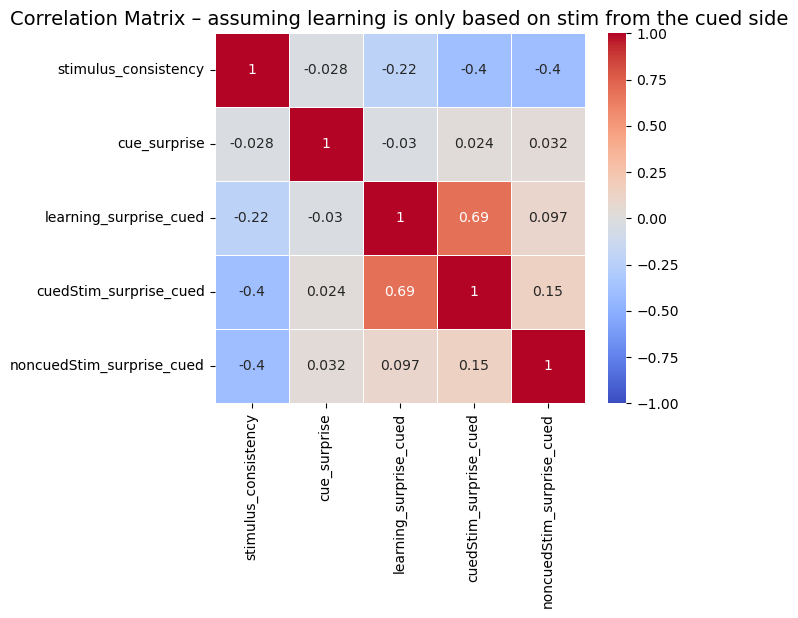

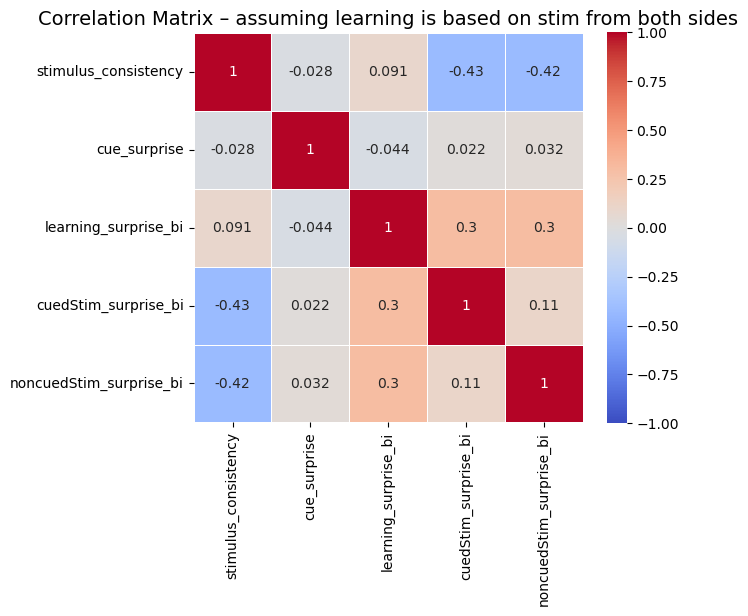

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

predictors1 = [
    "stimulus_consistency", "cue_surprise",
    "learning_surprise_cued", "cuedStim_surprise_cued",
    "noncuedStim_surprise_cued"
]

predictors2 = [
    "stimulus_consistency", "cue_surprise",
    "learning_surprise_bi", "cuedStim_surprise_bi",
    "noncuedStim_surprise_bi"
]

# Compute correlations
corr1 = all_pupil_v1[predictors1].corr()
corr2 = all_pupil_v1[predictors2].corr()

# --- heatmap function ---
def plot_corr_seaborn(corr, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        corr,
        annot=True,
        vmin=-1, vmax=1,        # >>> fixed color range <<<
        cmap="coolwarm",
        square=True,
        linewidths=0.5,
        linecolor="white"
    )
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# --- plot both ---
plot_corr_seaborn(corr1, "Correlation Matrix – assuming learning is only based on stim from the cued side")
plot_corr_seaborn(corr2, "Correlation Matrix – assuming learning is based on stim from both sides")


In [46]:
import statsmodels.formula.api as smf

def fit_pupil_models(all_pupil, predictors, pupil_metrics):
    """
    Fit mixed-effects models for multiple pupil metrics and print summaries.
    
    Parameters
    ----------
    all_pupil : pd.DataFrame
        Data containing all pupil metrics and predictors.
    predictors : list of str
        Names of predictor columns.
    pupil_metrics : list of str
        Names of dependent variables to loop through.
    
    Returns
    -------
    dict
        Keys are pupil metrics, values are fitted mixed-effects models.
    """
    models = {}
    
    for metric in pupil_metrics:
        # Convert dependent variable and predictors to numeric
        formula_cols = [metric] + predictors
        for col in formula_cols:
            all_pupil[col] = pd.to_numeric(all_pupil[col], errors='coerce')
        
        # Convert stimulus_consistency to int if it exists
        if 'stimulus_consistency' in predictors:
            all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)
        
        # Drop rows with missing data
        clean_data = all_pupil.dropna(subset=formula_cols) 
        clean_data = clean_data[clean_data['trial_index_within_block']<10]
        
        # Create formula
        formula = f"{metric} ~ " + " + ".join(predictors)
        
        # Fit mixed-effects model
        model = smf.mixedlm(formula, clean_data, groups=clean_data["subject"]).fit(reml=True)
        
        # Store model
        models[metric] = model
        
        # Print summary
        print(f"\n===== Mixed-Effects Model Summary for {metric} =====")
        print(model.summary())
    
    return models


In [21]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming `all_pupil_v1` is your data and contains the predictors
X = all_pupil_v1[predictors]  # Extract predictors
X = sm.add_constant(X)  # Add a constant term for the intercept

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


                    Variable       VIF
0                      const  9.272637
1       stimulus_consistency  1.243706
2               cue_surprise  1.002717
3     learning_surprise_cued  1.053313
4  noncuedStim_surprise_cued  1.193630


In [47]:
# pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio',
#                  'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']
pupil_metrics = ['max_pupilRatio']

# predictors = ["stimulus_consistency", "cue_surprise", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"]
predictors = ["stimulus_consistency", "cue_surprise", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"]
print("Assumption: people build the prior using ONLY CUED stimuli")
print("Here we exclude learning")
fitted_models = fit_pupil_models(all_pupil_v1, predictors, pupil_metrics)


Assumption: people build the prior using ONLY CUED stimuli
Here we exclude learning

===== Mixed-Effects Model Summary for max_pupilRatio =====
               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:     1658      Method:               REML          
No. Groups:           21        Scale:                0.0238        
Min. group size:      68        Log-Likelihood:       692.9222      
Max. group size:      81        Converged:            Yes           
Mean group size:      79.0                                          
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  1.179    0.028 41.591 0.000  1.123  1.235
stimulus_consistency      -0.044    0.009 -4.881 0.000 -0.062 -0.027
cue_surprise               0.007    0.013  0

In [48]:
pupil_metrics = ['max_pupilRatio']

# predictors = ["stimulus_consistency", "cue_surprise", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"]
predictors = ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "noncuedStim_surprise_cued"]
print("Assumption: people build the prior using ONLY CUED stimuli")
print("Here we exclude information gain from the cued side")
fitted_models = fit_pupil_models(all_pupil_v1, predictors, pupil_metrics)

Assumption: people build the prior using ONLY CUED stimuli
Here we exclude information gain from the cued side

===== Mixed-Effects Model Summary for max_pupilRatio =====
               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:     1658      Method:               REML          
No. Groups:           21        Scale:                0.0238        
Min. group size:      68        Log-Likelihood:       693.5531      
Max. group size:      81        Converged:            Yes           
Mean group size:      79.0                                          
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  1.174    0.028 42.177 0.000  1.119  1.229
stimulus_consistency      -0.043    0.009 -4.787 0.000 -0.060 -0.025
cue_surprise     

In [45]:
pupil_metrics = ['max_pupilRatio']

# predictors = ["stimulus_consistency", "cue_surprise", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"]
predictors = ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"]
print("Assumption: people build the prior using ONLY CUED stimuli")
print("Here we include both")
fitted_models = fit_pupil_models(all_pupil_v1, predictors, pupil_metrics)

Assumption: people build the prior using ONLY CUED stimuli
Here we include both

===== Mixed-Effects Model Summary for max_pupilRatio =====
               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:     1658      Method:               REML          
No. Groups:           21        Scale:                0.0238        
Min. group size:      68        Log-Likelihood:       690.8714      
Max. group size:      81        Converged:            Yes           
Mean group size:      79.0                                          
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  1.180    0.028 41.498 0.000  1.124  1.235
stimulus_consistency      -0.045    0.009 -4.888 0.000 -0.062 -0.027
cue_surprise               0.007    0.013  0.567

In [45]:
import statsmodels.formula.api as smf

def fit_pupil_models(all_pupil, predictors, pupil_metrics):
    """
    Fit mixed-effects models for multiple pupil metrics (z-score diff metrics) and print summaries.
    
    Parameters
    ----------
    all_pupil : pd.DataFrame
        Data containing all pupil metrics and predictors.
    predictors : list of str
        Names of predictor columns.
    pupil_metrics : list of str
        Names of dependent variables to loop through.
    
    Returns
    -------
    dict
        Keys are pupil metrics, values are fitted mixed-effects models.
    """
    # Define which metrics are "diff" metrics that need normalization
    diff_metrics = ['max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']
    
    # Z-score normalization for diff metrics
    for metric in diff_metrics:
        if metric in all_pupil.columns:
            all_pupil[metric + '_z'] = (all_pupil[metric] - all_pupil[metric].mean()) / all_pupil[metric].std()
    
    # Update metrics to use normalized versions for diff metrics
    pupil_metrics_norm = [
        m if m not in diff_metrics else m + '_z'
        for m in pupil_metrics
    ]
    
    models = {}
    
    for metric in pupil_metrics_norm:
        # Convert dependent variable and predictors to numeric
        formula_cols = [metric] + predictors
        for col in formula_cols:
            all_pupil[col] = pd.to_numeric(all_pupil[col], errors='coerce')
        
        # Convert stimulus_consistency to int if it exists
        if 'stimulus_consistency' in predictors:
            all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)
        
        # Drop rows with missing data
        clean_data = all_pupil.dropna(subset=formula_cols)
        
        # Create formula
        formula = f"{metric} ~ " + " + ".join(predictors)
        
        # Fit mixed-effects model
        model = smf.mixedlm(formula, clean_data, groups=clean_data["subject"]).fit(reml=True)
        
        # Store model
        models[metric] = model
        
        # Print summary
        print(f"\n===== Mixed-Effects Model Summary for {metric} =====")
        print(model.summary())
    
    return models

# Example usage
pupil_metrics = ['max_pupilRatio', 'mean_pupilSound_ratio', 'median_pupilSound_ratio',
                 'max_pupilSound_diff', 'mean_pupilSound_diff', 'median_pupilSound_diff']

predictors = ["stimulus_consistency", "cue_surprise", "learning_surprise_cued",
              "cuedStim_surprise_cued", "noncuedStim_surprise_cued"]

fitted_models = fit_pupil_models(all_pupil_v1, predictors, pupil_metrics)



===== Mixed-Effects Model Summary for max_pupilRatio =====
                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    max_pupilRatio
No. Observations:    5538       Method:                REML          
No. Groups:          21         Scale:                 0.0290        
Min. group size:     223        Log-Likelihood:        1860.2219     
Max. group size:     269        Converged:             Yes           
Mean group size:     263.7                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.200    0.027  44.829 0.000  1.147  1.252
stimulus_consistency      -0.059    0.005 -11.565 0.000 -0.069 -0.049
cue_surprise               0.017    0.006   2.758 0.006  0.005  0.029
learning_surprise_cued     0.000    0.000   0.

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



===== Mixed-Effects Model Summary for median_pupilSound_ratio =====
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: median_pupilSound_ratio
No. Observations: 5538    Method:             REML                   
No. Groups:       21      Scale:              0.0238                 
Min. group size:  223     Log-Likelihood:     2406.2737              
Max. group size:  269     Converged:          Yes                    
Mean group size:  263.7                                              
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.116    0.017  66.006 0.000  1.083  1.149
stimulus_consistency      -0.053    0.005 -11.450 0.000 -0.062 -0.044
cue_surprise               0.014    0.005   2.524 0.012  0.003  0.025
learning_surprise_cued     0.000    0

In [5]:
model1 = fit_pupil_model(all_pupil_v1, ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "cuedStim_surprise_cued", "noncuedStim_surprise_cued"])
print(model1.summary())

NameError: name 'fit_pupil_model' is not defined

In [24]:
model1 = fit_pupil_model(all_pupil_v1, ["stimulus_consistency", "cue_surprise", "learning_surprise_cued", "noncuedStim_surprise_cued"])
print(model1.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:     5538      Method:               REML          
No. Groups:           21        Scale:                0.0290        
Min. group size:      223       Log-Likelihood:       1882.6715     
Max. group size:      269       Converged:            Yes           
Mean group size:      263.7                                         
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  1.187    0.027 43.837 0.000  1.134  1.240
stimulus_consistency      -0.053    0.005 -9.714 0.000 -0.064 -0.042
cue_surprise               0.016    0.006  2.660 0.008  0.004  0.028
learning_surprise_cued     0.007    0.024  0.279 0.781 -0.040  0.053
noncuedStim_surprise_cued  0.018    0.005  3.335 0

pvals shape: (21, 100, 2, 5)


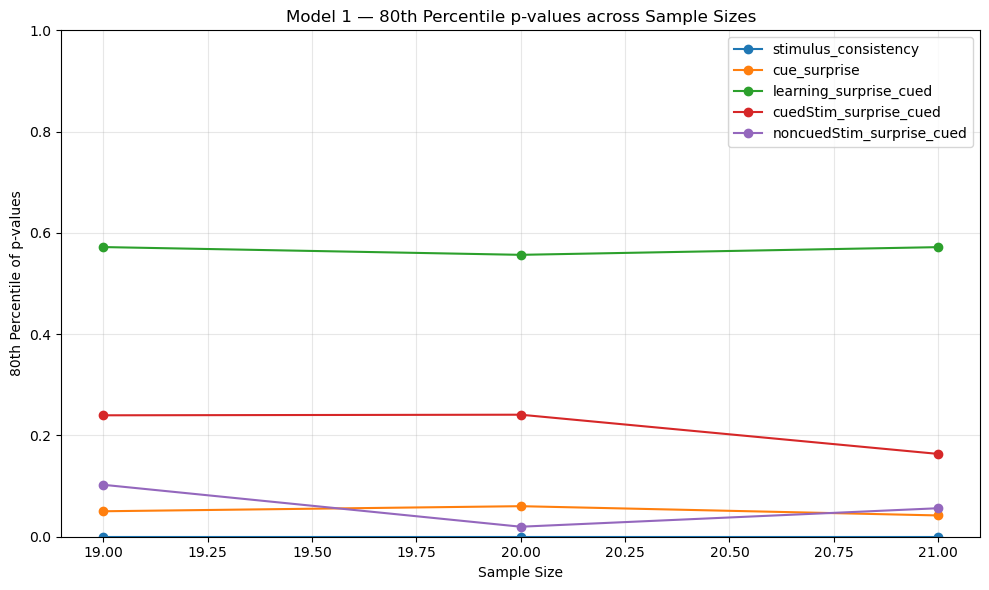

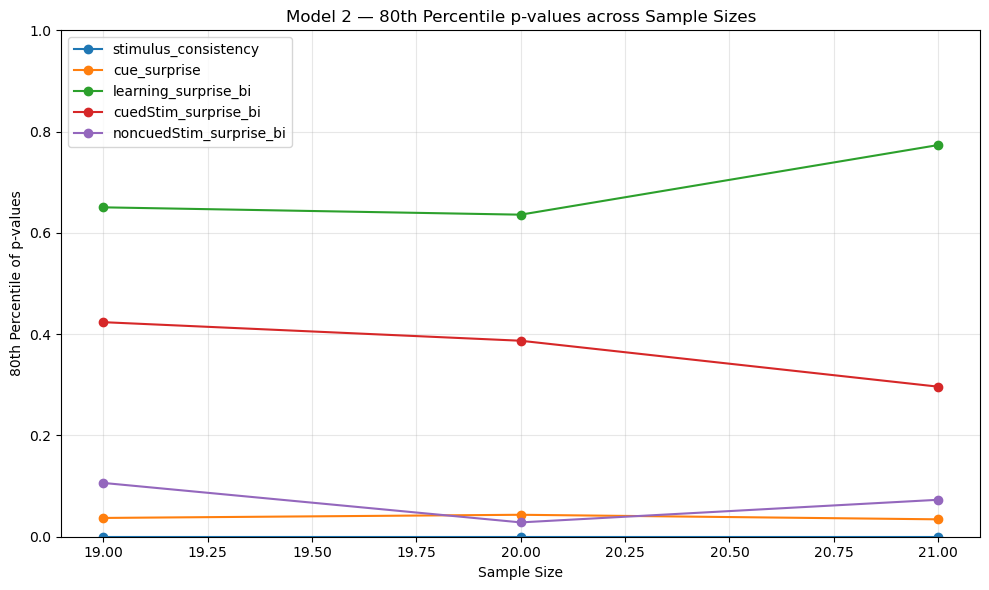

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load results
# -----------------------------
data = np.load("pupil_power_progress.npz", allow_pickle=True)
pvals = data["pvals"]          # shape = (n_sizes, n_repeats, 2, 5)
sample_sizes = data["sample_sizes"]  # list of sample sizes

n_sizes, n_repeats, n_models, n_predictors = pvals.shape
print("pvals shape:", pvals.shape)

# Predictor names must match your models
model_predictors = {
    0: ["stimulus_consistency", "cue_surprise", "learning_surprise_cued",
        "cuedStim_surprise_cued", "noncuedStim_surprise_cued"],

    1: ["stimulus_consistency", "cue_surprise", "learning_surprise_bi",
        "cuedStim_surprise_bi", "noncuedStim_surprise_bi"]
}

# -----------------------------
# Compute 80th percentiles
# -----------------------------

# perc80[model][predictor][sample_size_index]
perc80 = np.percentile(pvals, 80, axis=1)   # shape: (n_sizes, 2, 5)

# After percentile: shape = (n_sizes, 2, 5)
# Convert to (2 models, 5 predictors, n_sizes) for easier plotting
perc80 = np.transpose(perc80, (1, 2, 0))

# -----------------------------
# Plot each model
# -----------------------------
for model_index in [0, 1]:
    predictors = model_predictors[model_index]

    plt.figure(figsize=(10, 6))
    for pred_index, pred_name in enumerate(predictors):
        plt.plot(sample_sizes,
                 perc80[model_index][pred_index],
                 marker='o',
                 label=pred_name)

    plt.xlabel("Sample Size")
    plt.ylabel("80th Percentile of p-values")
    plt.title(f"Model {model_index+1} — 80th Percentile p-values across Sample Sizes")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [47]:
def fit_pupil_model(all_pupil, predictors):
    formula_cols = ["max_pupilRatio"] + predictors
    for col in formula_cols:
        all_pupil[col] = pd.to_numeric(all_pupil[col], errors='coerce')
    if 'stimulus_consistency' in predictors:
        all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)
    clean_data = all_pupil.dropna(subset=formula_cols)
    formula = "max_pupilRatio ~ " + " + ".join(predictors)
    model = smf.mixedlm(formula, clean_data, groups=clean_data["subject"]).fit(reml=True)
    return model

In [50]:
model1 = fit_pupil_model(all_pupil_v1, ["stimulus_consistency", "cue_surprise", "learning_surprise_bi", "cuedStim_surprise_bi", "noncuedStim_surprise_bi"])
print("Assumption: people build the prior using BOTH cued and noncued stimuli")
print("Here we include both")
print(model1.summary())

Assumption: people build the prior using BOTH cued and noncued stimuli
Here we include both
              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:   5538      Method:               REML          
No. Groups:         21        Scale:                0.0289        
Min. group size:    223       Log-Likelihood:       1882.4931     
Max. group size:    269       Converged:            Yes           
Mean group size:    263.7                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                1.175    0.028 42.633 0.000  1.121  1.229
stimulus_consistency    -0.047    0.007 -7.120 0.000 -0.060 -0.034
cue_surprise             0.016    0.006  2.651 0.008  0.004  0.028
learning_surprise_bi     0.009    0.016  0.540 0.590

In [40]:
model2 = fit_pupil_model(all_pupil_v1, ["stimulus_consistency", "cue_surprise", "cuedStim_surprise_bi", "noncuedStim_surprise_bi"])
print("Assumption: people build the prior using BOTH cued and noncued stimuli")
print("Here we exclude learning")
print(model2.summary())

Assumption: people build the prior using BOTH cued and noncued stimuli
Here we exclude learning
              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:   5538      Method:               REML          
No. Groups:         21        Scale:                0.0289        
Min. group size:    223       Log-Likelihood:       1885.5728     
Max. group size:    269       Converged:            Yes           
Mean group size:    263.7                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                1.174    0.027 42.876 0.000  1.120  1.227
stimulus_consistency    -0.045    0.006 -7.621 0.000 -0.057 -0.034
cue_surprise             0.016    0.006  2.622 0.009  0.004  0.028
cuedStim_surprise_bi     0.014    0.005  2.709 0

In [37]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Assuming your dataset is named 'clean_data'
predictors = ["stimulus_consistency", "cue_surprise", "learning_surprise_bi", "cuedStim_surprise_bi", "noncuedStim_surprise_bi"]

# Extract the predictors
X = all_pupil_v1[predictors]  # Make sure to use your actual dataframe here
X = sm.add_constant(X)  # Add a constant term for the intercept

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


                  Variable        VIF
0                    const  14.578576
1     stimulus_consistency   1.820696
2             cue_surprise   1.005896
3     learning_surprise_bi   1.464516
4     cuedStim_surprise_bi   1.538786
5  noncuedStim_surprise_bi   1.530224


In [38]:
model2 = fit_pupil_model(all_pupil_v1, ["stimulus_consistency", "cue_surprise", "learning_surprise_bi", "noncuedStim_surprise_bi"])
print("Assumption: people build the prior using BOTH cued and noncued stimuli")
print("Here we exclude information gain from the cued side")
print(model2.summary())

Assumption: people build the prior using both cued and noncued stimuli
Here we exclude information gain from the cued side
              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   max_pupilRatio
No. Observations:   5538      Method:               REML          
No. Groups:         21        Scale:                0.0289        
Min. group size:    223       Log-Likelihood:       1884.3361     
Max. group size:    269       Converged:            Yes           
Mean group size:    263.7                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                1.188    0.027 43.967 0.000  1.135  1.241
stimulus_consistency    -0.055    0.006 -9.799 0.000 -0.066 -0.044
cue_surprise             0.017    0.006  2.737 0.006  0.005  0.028
learning_surprise_bi 